# 2023년 요일별 지하철 사용량 vs 실제 사용 대수 비교

- 지하철 사용량 기준: `analystics_sub_new_23`와 동일하게 `여의도`, `여의나루`역 사용
- 지하철 집계: 두 역의 `승차+하차`를 모두 합산한 일별 총사용량
- 실제 사용 대수 기준: `Data/한강공원 주차장 일별 이용 현황.csv`의 `PLT-008` 2023년 `주차대수` 일합계
- 비교 방식: `월요일~일요일`로 다시 합산한 뒤 `raw 비교`와 `0~1 scaled 비교`를 함께 시각화


In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mplconfig-team_pl")

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
PROJECT_ROOT = next(
    (path for path in candidates if (path / "Data").exists() and (path / "Note").exists()),
    cwd,
)

METRO_PATH = PROJECT_ROOT / "Data/Metro/서울교통공사_역별 시간대별 승하차인원(23.1~23.12) (1).csv"
PARKING_RAW_PATH = PROJECT_ROOT / "Data/한강공원 주차장 일별 이용 현황.csv"

OUTPUT_PLOT_PATH = PROJECT_ROOT / "Data/outputs/subway_actual_weekday_compare_2023.png"
OUTPUT_SUMMARY_PATH = PROJECT_ROOT / "Data/outputs/subway_actual_weekday_compare_2023.csv"
OUTPUT_DAILY_PATH = PROJECT_ROOT / "Data/outputs/subway_actual_weekday_daily_2023.csv"

SELECTED_STATIONS = ["여의도", "여의나루"]
WEEKDAY_ORDER = [
    (0, "월요일"),
    (1, "화요일"),
    (2, "수요일"),
    (3, "목요일"),
    (4, "금요일"),
    (5, "토요일"),
    (6, "일요일"),
]


In [2]:
def configure_matplotlib() -> None:
    font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in font_candidates:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            break
    plt.rcParams["axes.unicode_minus"] = False


def scale_to_zero_one(series: pd.Series) -> pd.Series:
    min_value = series.min()
    max_value = series.max()
    if pd.isna(min_value) or pd.isna(max_value) or min_value == max_value:
        return pd.Series(0.0, index=series.index, dtype=float)
    return (series - min_value) / (max_value - min_value)


def load_subway_daily() -> pd.DataFrame:
    subway_df = pd.read_csv(METRO_PATH, encoding="cp949")

    station_col = "역명"
    date_col = "수송일자" if "수송일자" in subway_df.columns else "날짜"
    time_order = [
        "06시이전", "06시 이전", "06-07시간대", "06시-07시", "07-08시간대", "07시-08시",
        "08-09시간대", "08시-09시", "09-10시간대", "09시-10시", "10-11시간대", "10시-11시",
        "11-12시간대", "11시-12시", "12-13시간대", "12시-13시", "13-14시간대", "13시-14시",
        "14-15시간대", "14시-15시", "15-16시간대", "15시-16시", "16-17시간대", "16시-17시",
        "17-18시간대", "17시-18시", "18-19시간대", "18시-19시", "19-20시간대", "19시-20시",
        "20-21시간대", "20시-21시", "21-22시간대", "21시-22시", "22-23시간대", "22시-23시",
        "23-24시간대", "23시-24시", "24시이후", "24시 이후"
    ]
    hour_cols = [col for col in time_order if col in subway_df.columns]

    filtered_df = subway_df[subway_df[station_col].isin(SELECTED_STATIONS)].copy()
    filtered_df[date_col] = pd.to_datetime(filtered_df[date_col])
    filtered_df["subway_total"] = filtered_df[hour_cols].sum(axis=1)

    subway_daily_df = (
        filtered_df.groupby(date_col, as_index=False)["subway_total"]
        .sum()
        .rename(columns={date_col: "일자"})
        .sort_values("일자")
        .reset_index(drop=True)
    )
    return subway_daily_df


def load_actual_daily() -> pd.DataFrame:
    parking_raw_df = pd.read_csv(PARKING_RAW_PATH, encoding="cp949")
    parking_raw_df["날짜"] = pd.to_datetime(parking_raw_df["날짜"])

    actual_daily_df = (
        parking_raw_df[
            (parking_raw_df["지구별"] == "PLT-008")
            & (parking_raw_df["날짜"].dt.year == 2023)
        ]
        .groupby("날짜", as_index=False)["주차대수"]
        .sum()
        .rename(columns={"날짜": "일자", "주차대수": "actual_usage"})
        .sort_values("일자")
        .reset_index(drop=True)
    )
    return actual_daily_df


def build_merged_daily() -> pd.DataFrame:
    subway_daily_df = load_subway_daily()
    actual_daily_df = load_actual_daily()

    merged_daily_df = (
        subway_daily_df.merge(actual_daily_df, on="일자", how="inner")
        .sort_values("일자")
        .reset_index(drop=True)
    )
    merged_daily_df["weekday_num"] = merged_daily_df["일자"].dt.dayofweek
    merged_daily_df["요일"] = merged_daily_df["weekday_num"].map(dict(WEEKDAY_ORDER))
    return merged_daily_df


def build_weekday_summary_df(merged_daily_df: pd.DataFrame) -> pd.DataFrame:
    summary_df = (
        merged_daily_df.groupby(["weekday_num", "요일"], as_index=False)
        .agg(
            subway_total_sum=("subway_total", "sum"),
            actual_usage_sum=("actual_usage", "sum"),
            표본일수=("일자", "size"),
        )
        .sort_values("weekday_num")
        .reset_index(drop=True)
    )
    summary_df["subway_scaled_0_1"] = scale_to_zero_one(summary_df["subway_total_sum"])
    summary_df["actual_scaled_0_1"] = scale_to_zero_one(summary_df["actual_usage_sum"])
    summary_df["weekday_corr_7pt"] = summary_df["subway_total_sum"].corr(summary_df["actual_usage_sum"])
    return summary_df


def plot_weekday_compare(summary_df: pd.DataFrame) -> None:
    configure_matplotlib()

    traffic_color = "#1f77b4"
    actual_color = "#ff7f0e"
    x_positions = list(range(len(summary_df)))

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    ax_raw = axes[0]
    ax_raw_right = ax_raw.twinx()
    ax_raw.plot(x_positions, summary_df["subway_total_sum"], color=traffic_color, linewidth=2.4, marker="o", label="지하철 합산값")
    ax_raw_right.plot(x_positions, summary_df["actual_usage_sum"], color=actual_color, linewidth=2.4, marker="o", label="실제 사용 대수 합산값")
    ax_raw.set_xticks(x_positions)
    ax_raw.set_xticklabels(summary_df["요일"])
    ax_raw.set_xlabel("요일")
    ax_raw.set_ylabel("지하철 합산값")
    ax_raw_right.set_ylabel("실제 사용 대수 합산값")
    ax_raw.set_title("요일별 합산 raw 비교")
    ax_raw.grid(axis="y", alpha=0.25)

    ax_scaled = axes[1]
    ax_scaled.plot(x_positions, summary_df["subway_scaled_0_1"], color=traffic_color, linewidth=2.6, marker="o", markersize=7, label="지하철 합산값 (0~1 scaled)")
    ax_scaled.plot(x_positions, summary_df["actual_scaled_0_1"], color=actual_color, linewidth=2.6, marker="o", markersize=7, label="실제 사용 대수 합산값 (0~1 scaled)")
    for idx, row in summary_df.iterrows():
        ax_scaled.text(idx, row["subway_scaled_0_1"] + 0.04, f"{row['subway_scaled_0_1']:.2f}", color=traffic_color, fontsize=10, ha="center", va="bottom")
        ax_scaled.text(idx, row["actual_scaled_0_1"] - 0.06, f"{row['actual_scaled_0_1']:.2f}", color=actual_color, fontsize=10, ha="center", va="top")
    ax_scaled.set_xticks(x_positions)
    ax_scaled.set_xticklabels(summary_df["요일"])
    ax_scaled.set_xlabel("요일")
    ax_scaled.set_ylabel("0~1 scaled value")
    ax_scaled.set_ylim(-0.1, 1.1)
    ax_scaled.set_title("요일별 합산 0~1 scaled 비교")
    ax_scaled.grid(axis="y", alpha=0.25)
    ax_scaled.legend(frameon=False, loc="lower left")
    corr_value = float(summary_df["weekday_corr_7pt"].iloc[0])
    ax_scaled.text(0.98, 0.98, f"7-point corr = {corr_value:.3f}", transform=ax_scaled.transAxes, ha="right", va="top", fontsize=11, bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#d0d0d0", "alpha": 0.9})

    fig.suptitle("2023년 요일별 지하철 사용량 vs 실제 사용 대수 비교", fontsize=17, y=0.99)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(OUTPUT_PLOT_PATH, dpi=200, bbox_inches="tight")
    plt.show()


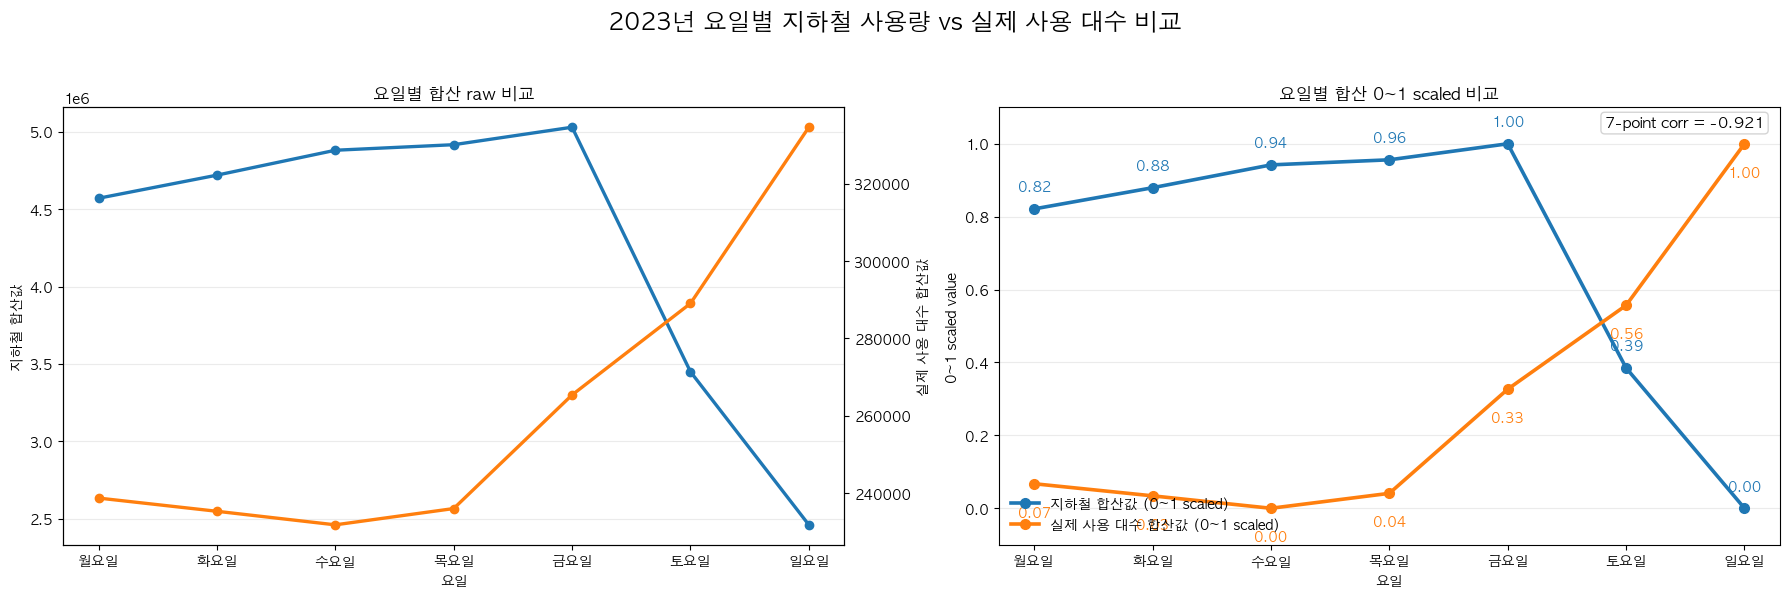

Saved plot: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/outputs/subway_actual_weekday_compare_2023.png
Saved summary table: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/outputs/subway_actual_weekday_compare_2023.csv
Saved merged daily data: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/outputs/subway_actual_weekday_daily_2023.csv


,weekday_num,요일,subway_total_sum,actual_usage_sum,표본일수,subway_scaled_0_1,actual_scaled_0_1,weekday_corr_7pt
0,0,월요일,4570494,238727,52,0.821339,0.067327,-0.920987
1,1,화요일,4719727,235311,52,0.879432,0.034101,-0.920987
2,2,수요일,4880654,231805,52,0.942077,0.000000,-0.920987
3,3,목요일,4916509,236019,52,0.956035,0.040988,-0.920987
4,4,금요일,5029450,265393,52,1.000000,0.326697,-0.920987
5,5,토요일,3449689,289050,52,0.385034,0.556798,-0.920987
6,6,일요일,2460592,334616,51,0.000000,1.000000,-0.920987


In [3]:
merged_daily_df = build_merged_daily()
summary_df = build_weekday_summary_df(merged_daily_df)

merged_daily_df.to_csv(OUTPUT_DAILY_PATH, index=False, encoding="utf-8-sig")
summary_df.to_csv(OUTPUT_SUMMARY_PATH, index=False, encoding="utf-8-sig")

plot_weekday_compare(summary_df)

print(f"Saved plot: {OUTPUT_PLOT_PATH}")
print(f"Saved summary table: {OUTPUT_SUMMARY_PATH}")
print(f"Saved merged daily data: {OUTPUT_DAILY_PATH}")
summary_df
